In [31]:

suppressPackageStartupMessages({
  library(tidyverse)
  library(tibble)
  library(scales)
  library(GenomicRanges)
  library(IRanges)
  library(survival)
  library(survminer)
  library(grid)
  library(ggforce)
  library(ggpubr)
  library(ggrepel)
  library(ComplexHeatmap)
  library(circlize)
  library(forcats)
  library(valr)
})

In [14]:
# Paths to the directories
# ==================================================
setwd("/home/mjehangir/telomere-sv-analysis/data/")
fig3_dir <- "/home/mjehangir/telomere-sv-analysis/plots/fig3/"
fig6_dir <- "/home/mjehangir/telomere-sv-analysis/plots/fig6/"
base_dir <- "/home/mjehangir/softwares/SVAN/chm13"

In [15]:
# Helpers function
# ==================================================
theme_pub <- function(base_size = 12) {
  theme_classic(base_size = base_size) +
    theme(
      axis.line = element_line(linewidth = 0.5, colour = "black"),
      axis.ticks = element_line(linewidth = 0.5, colour = "black"),
      axis.text = element_text(colour = "black"),
      axis.title = element_text(face = "bold", colour = "black"),
      plot.title = element_text(face = "bold", hjust = 0.5),
      panel.background = element_blank(),
      plot.background = element_blank()
    )
}

save_pdf <- function(plot, filename, width, height) {
  ggsave(filename = filename, plot = plot, device = "pdf",
         width = width, height = height, units = "in", dpi = 300)
}

In [16]:
# Load data
# ==================================================
ecbed <- read.delim("all_samples_reconstruct.ecDNA.filtered.bed", header = TRUE, sep = "\t")
colnames(ecbed)[9] <- "sample"
colnames(ecbed)[1] <- "chr"

ecdna <- read.delim("all_samples_summary.tsv", sep = "\t", header = TRUE)
chr_arm_size <- read.csv("chm13_p_q_arm_length.tsv", header = TRUE, sep = "\t")
telomeres_MAD <- read.table("telomeres_MAD.txt", sep = "\t", header = TRUE, check.names = FALSE)

# Quick checks
print(table(ecdna$topology_name))
print(table(ecdna$label))


             foldbacks multi_region_inter_chr multi_region_intra_chr 
                     3                     22                     42 
         simple_circle    simple_duplications              simple_sv 
                   208                      1                     14 

      ecDNA 
  245    45 


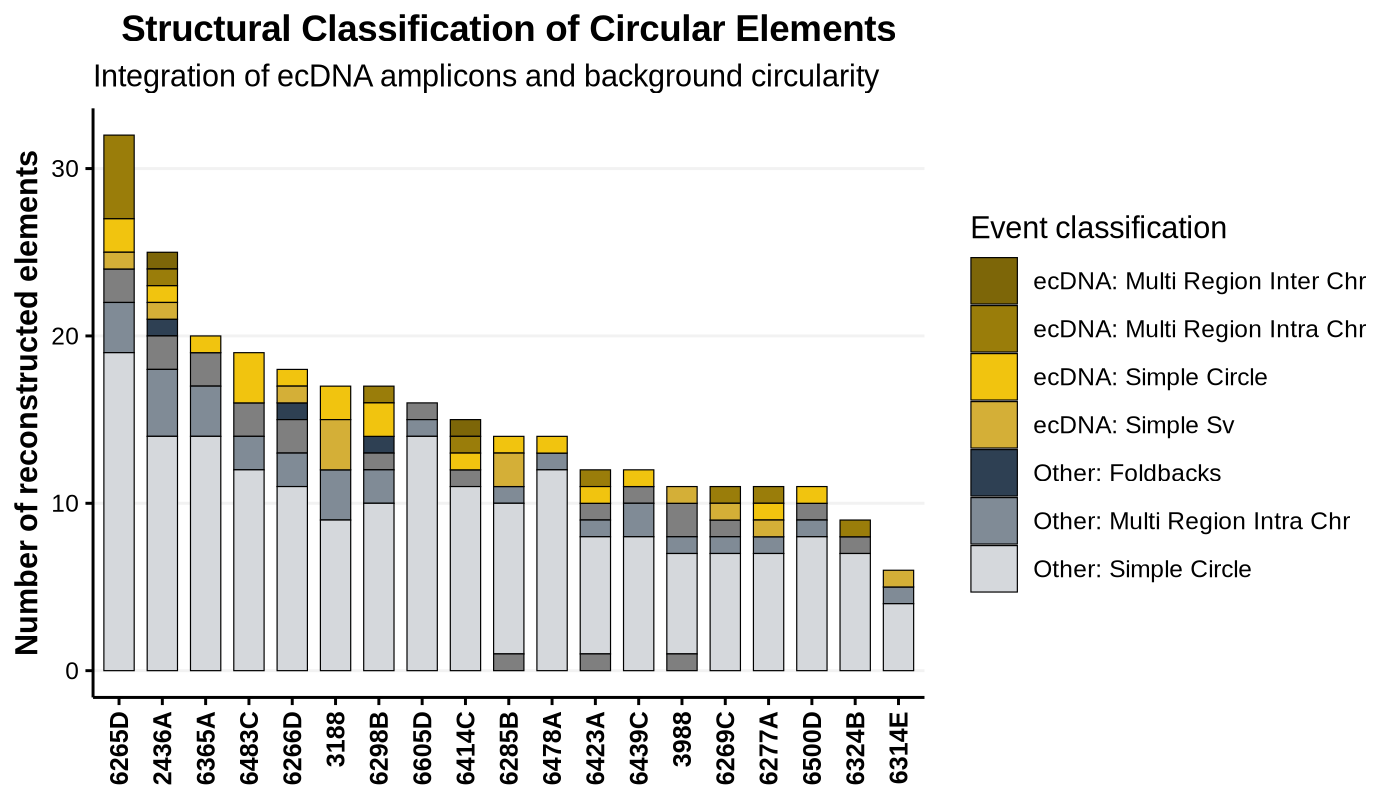

In [17]:
#  Structural classification of circular elements
# ==================================================
ecdna_plot_df <- ecdna %>%
  mutate(
    clean_topology = gsub("_", " ", topology_name) %>% tools::toTitleCase(),
    plot_type = ifelse(label == "ecDNA",
                       paste("ecDNA:", clean_topology),
                       paste("Other:", clean_topology))
  ) %>%
  group_by(sample, plot_type) %>%
  summarise(count = n(), .groups = "drop")

p_structural <- ggplot(ecdna_plot_df, aes(x = reorder(sample, -count, sum), y = count, fill = plot_type)) +
  geom_col(color = "black", linewidth = 0.2, width = 0.7) +
  scale_fill_manual(values = c(
    "ecDNA: Simple Circle" = "#F1C40F",
    "ecDNA: Simple Sv" = "#D4AF37",
    "ecDNA: Multi Region Intra Chr" = "#9A7D0A",
    "ecDNA: Multi Region Inter Chr" = "#7D6608",
    "Other: Simple Circle" = "#D5D8DC",
    "Other: Multi Region Intra Chr" = "#808B96",
    "Other: Foldbacks" = "#2E4053"
  )) +
  labs(
    title = "Structural Classification of Circular Elements",
    subtitle = "Integration of ecDNA amplicons and background circularity",
    x = NULL,
    y = "Number of reconstructed elements",
    fill = "Event classification"
  ) +
  theme_pub(11) +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, face = "bold", size = 9),
    legend.position = "right",
    panel.grid.major.y = element_line(color = "grey95")
  )

print(p_structural)

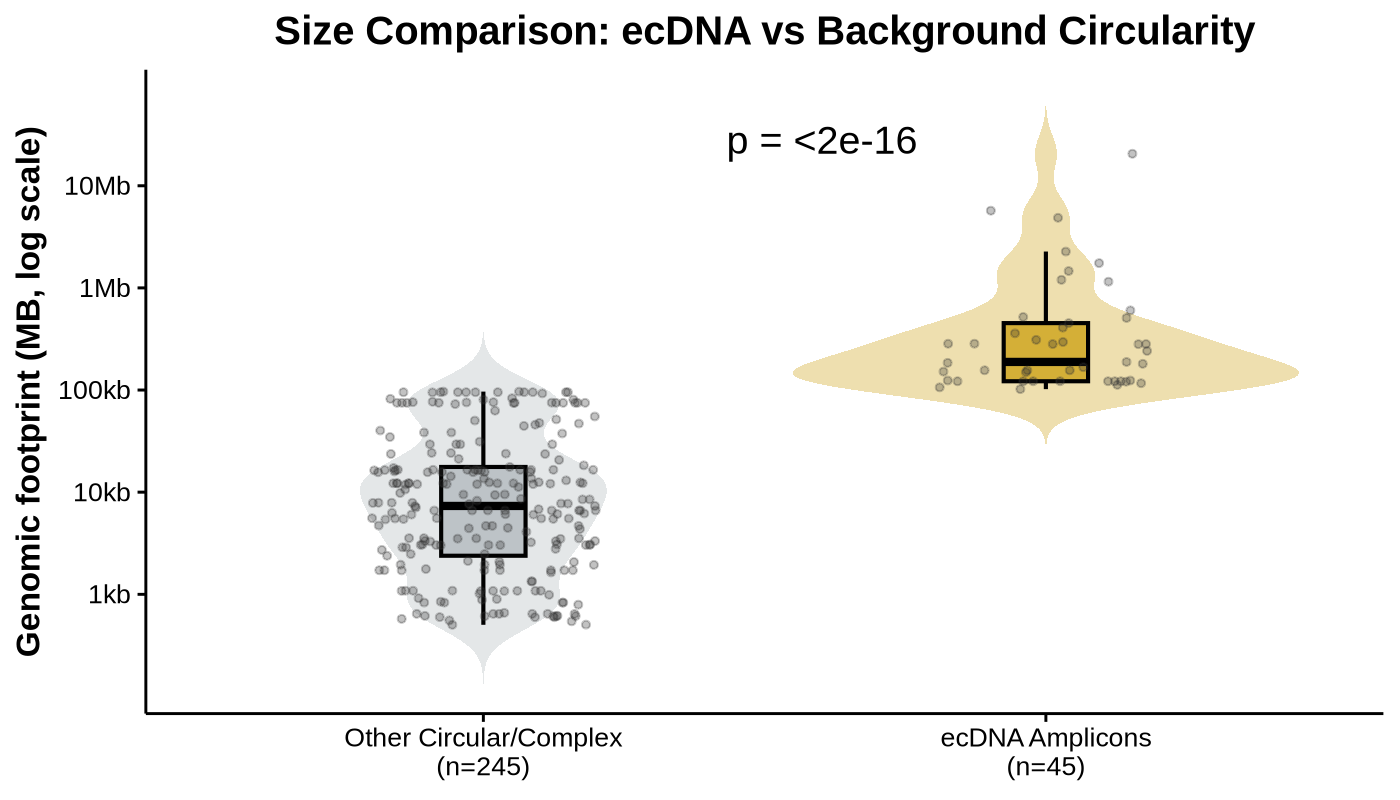

In [18]:
#  Size comparison: ecDNA vs other circles
# ==================================================
df_size_comp <- ecdna %>%
  mutate(
    Category = ifelse(label == "ecDNA", "ecDNA Amplicons", "Other Circular/Complex"),
    Category = factor(Category, levels = c("Other Circular/Complex", "ecDNA Amplicons"))
  )

cat_counts <- df_size_comp %>% count(Category)
x_labels <- setNames(
  paste0(cat_counts$Category, "\n(n=", cat_counts$n, ")"),
  cat_counts$Category
)

p_size_compare <- ggplot(df_size_comp, aes(x = Category, y = size.MB., fill = Category)) +
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  geom_boxplot(width = 0.15, color = "black", outlier.shape = NA, linewidth = 0.7) +
  geom_jitter(width = 0.2, alpha = 0.3, size = 1, color = "grey20") +
  scale_y_log10(
    breaks = c(0.001, 0.01, 0.1, 1, 10),
    labels = c("1kb", "10kb", "100kb", "1Mb", "10Mb")
  ) +
  scale_x_discrete(labels = x_labels) +
  scale_fill_manual(values = c(
    "Other Circular/Complex" = "#BDC3C7",
    "ecDNA Amplicons" = "#D4AF37"
  )) +
  stat_compare_means(method = "wilcox.test", label = "p.format", label.x = 1.5, size = 5) +
  labs(
    title = "Size Comparison: ecDNA vs Background Circularity",
    x = NULL,
    y = "Genomic footprint (MB, log scale)"
  ) +
  theme_pub(12) +
  theme(legend.position = "none")

print(p_size_compare)
#save_pdf(p_size_compare, file.path(fig6_dir, "size_ecDNA_Fragments.pdf"), 4, 4)

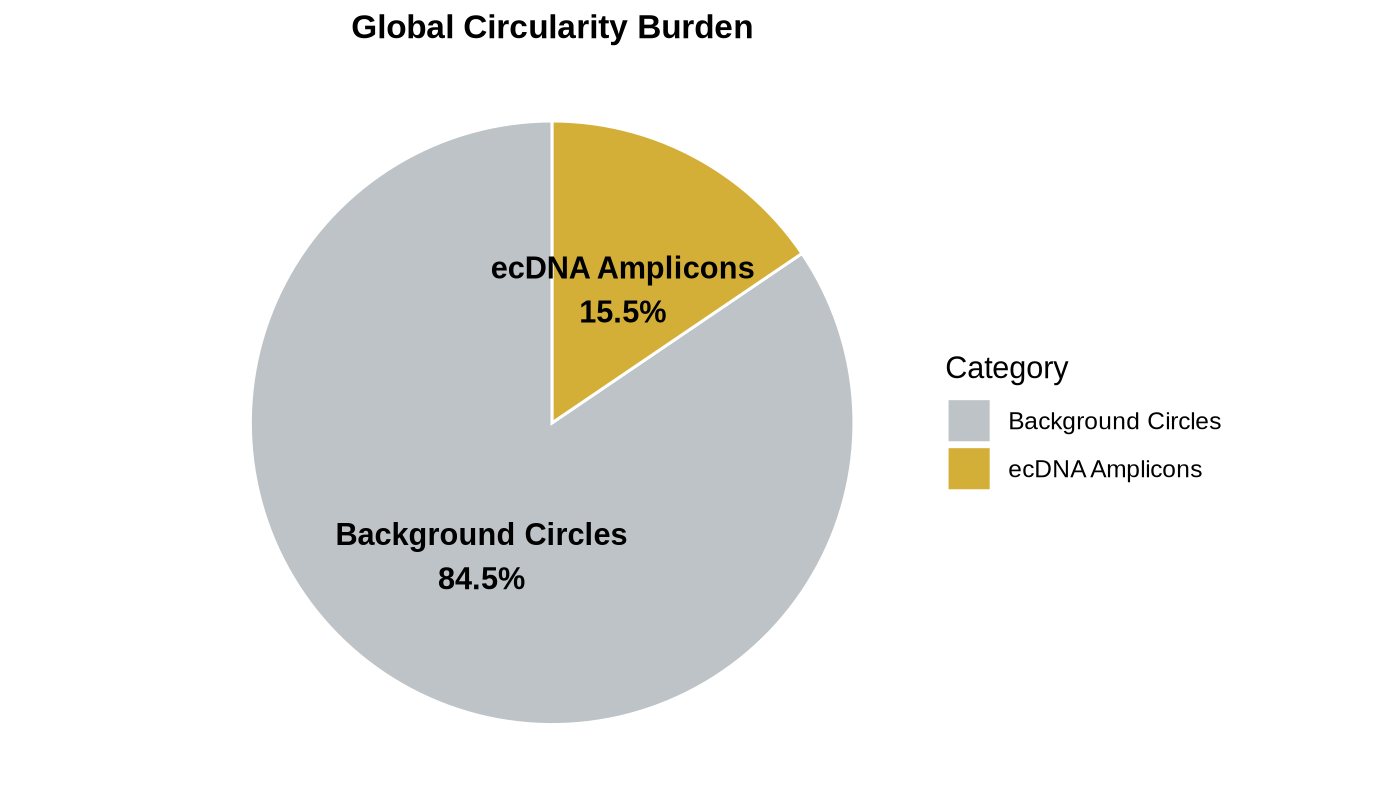

In [30]:
# ---  Global Pie Chart (All circular elements) ---
# Separates ecDNA amplicons from the background pool
pie_df <- ecdna %>%
  mutate(Category = ifelse(label == "ecDNA", "ecDNA Amplicons", "Background Circles")) %>%
  group_by(Category) %>%
  summarise(count = n()) %>%
  mutate(perc = count / sum(count) * 100,
         label = paste0(Category, "\n", round(perc, 1), "%"))

p1 <- ggplot(pie_df, aes(x = "", y = count, fill = Category)) +
  geom_bar(stat = "identity", width = 1, color = "white") +
  coord_polar("y", start = 0) +
  scale_fill_manual(values = c("ecDNA Amplicons" = "#D4AF37", "Background Circles" = "#BDC3C7")) +
  theme_void() +
  labs(title = "Global Circularity Burden") +
  geom_text(aes(label = label), position = position_stack(vjust = 0.5), fontface = "bold") +
  theme(plot.title = element_text(hjust = 0.5, face = "bold", size = 12))
p1

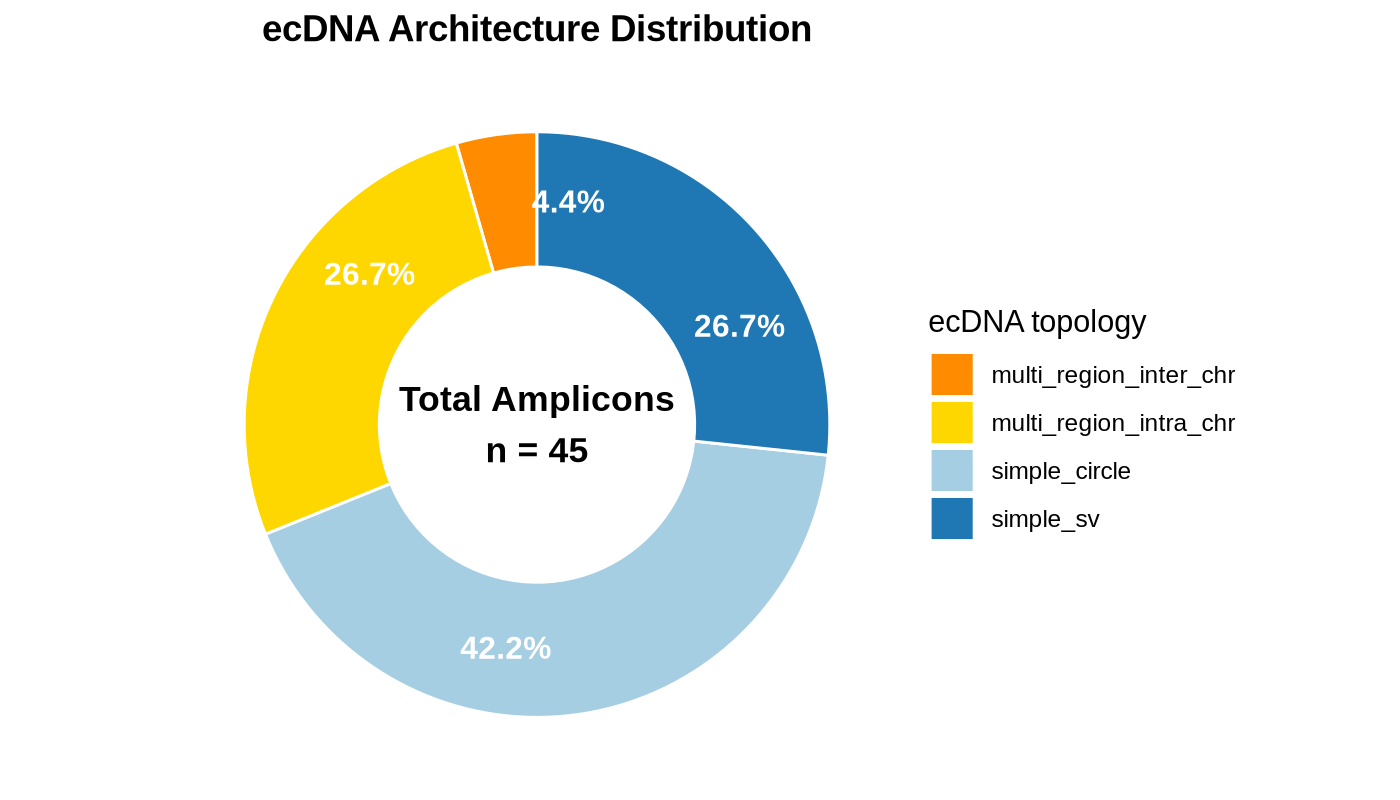

In [19]:
#  Donut plot of ecDNA topologies
# ==================================================
topo_colors <- c(
  "simple_circle" = "#A6CEE3",
  "simple_sv" = "#1F78B4",
  "simple_duplications" = "#B2DF8A",
  "foldbacks" = "#E31A1C",
  "multi_region_inter_chr" = "#FF8C00",
  "multi_region_intra_chr" = "#FFD700"
)

donut_df <- ecdna %>%
  filter(label == "ecDNA") %>%
  mutate(topology_name = tolower(gsub(" ", "_", topology_name))) %>%
  group_by(topology_name) %>%
  summarise(count = n(), .groups = "drop") %>%
  mutate(
    percentage = count / sum(count) * 100,
    label_text = paste0(round(percentage, 1), "%"),
    ymax = cumsum(count),
    ymin = c(0, head(ymax, n = -1)),
    label_pos = (ymax + ymin) / 2
  )

p_donut <- ggplot(donut_df, aes(x = 2, y = count, fill = topology_name)) +
  geom_col(color = "white", linewidth = 0.5) +
  coord_polar("y", start = 0) +
  xlim(0.5, 2.5) +
  scale_fill_manual(values = topo_colors, name = "ecDNA topology") +
  geom_text(aes(y = label_pos, label = label_text), color = "white", fontface = "bold", size = 4) +
  annotate("text", x = 0.5, y = 0,
           label = paste0("Total Amplicons\nn = ", sum(donut_df$count)),
           fontface = "bold", size = 4.5, color = "black") +
  labs(title = "ecDNA Architecture Distribution") +
  theme_void() +
  theme(plot.title = element_text(face = "bold", hjust = 0.5), legend.position = "right")

print(p_donut)
#save_pdf(p_donut, file.path(fig6_dir, "ecDNA_donutplot.pdf"), 5, 5)

   sample ecDNA_count
1   2436A           4
2    3188           5
3    3988           1
4   6265D           8
5   6266D           2
6   6269C           2
7   6277A           3
8   6285B           3
9   6298B           3
10  6314E           1
11  6324B           1
12  6365A           1
13  6414C           3
14  6423A           2
15  6439C           1
16  6478A           1
17  6483C           3
18  6500D           1
   sample fragments_count
1   2436A              12
2    3188               8
3    3988               3
4   6265D              18
5   6266D               3
6   6269C               5
7   6277A               7
8   6285B               5
9   6298B               6
10  6314E               2
11  6324B               3
12  6365A               1
13  6414C              16
14  6423A               5
15  6439C               1
16  6478A               1
17  6483C               3
18  6500D               1


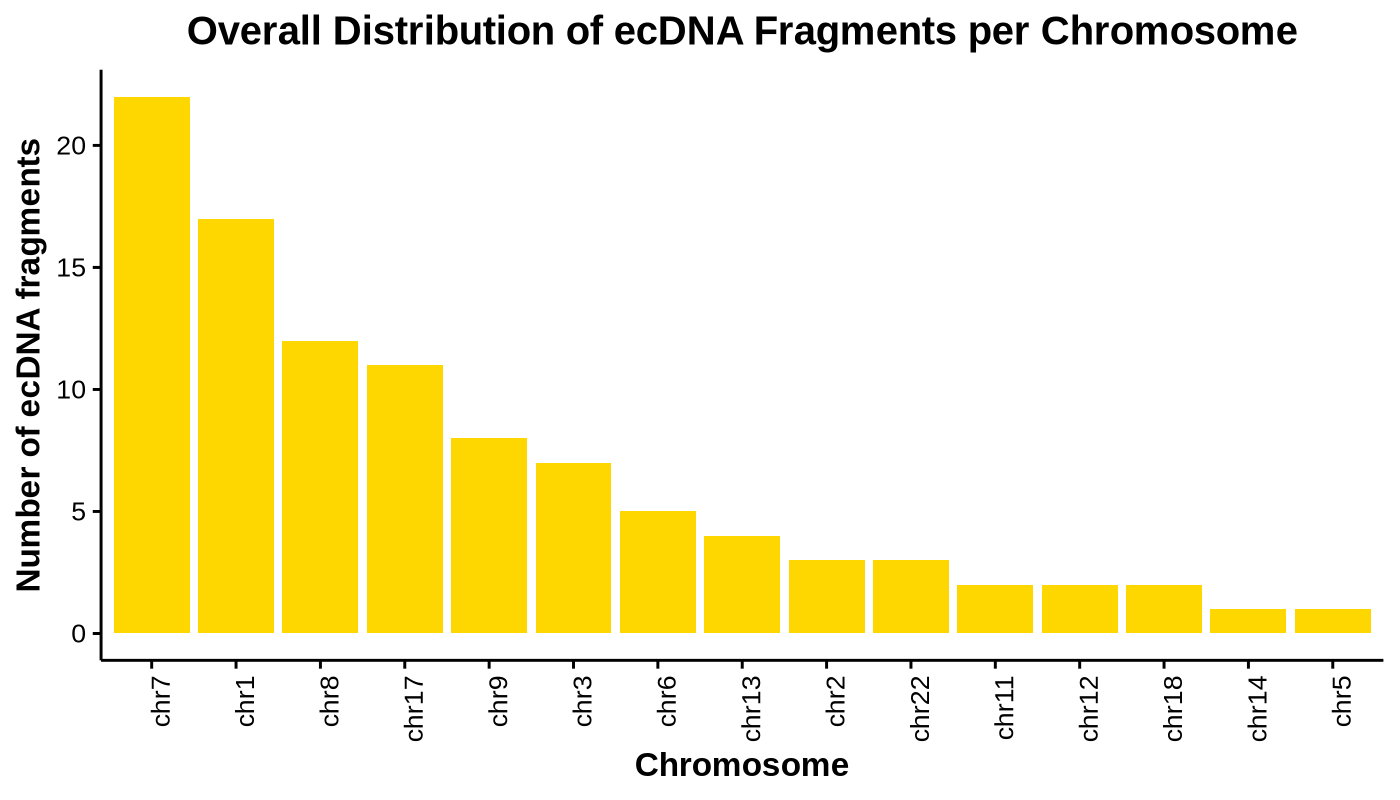

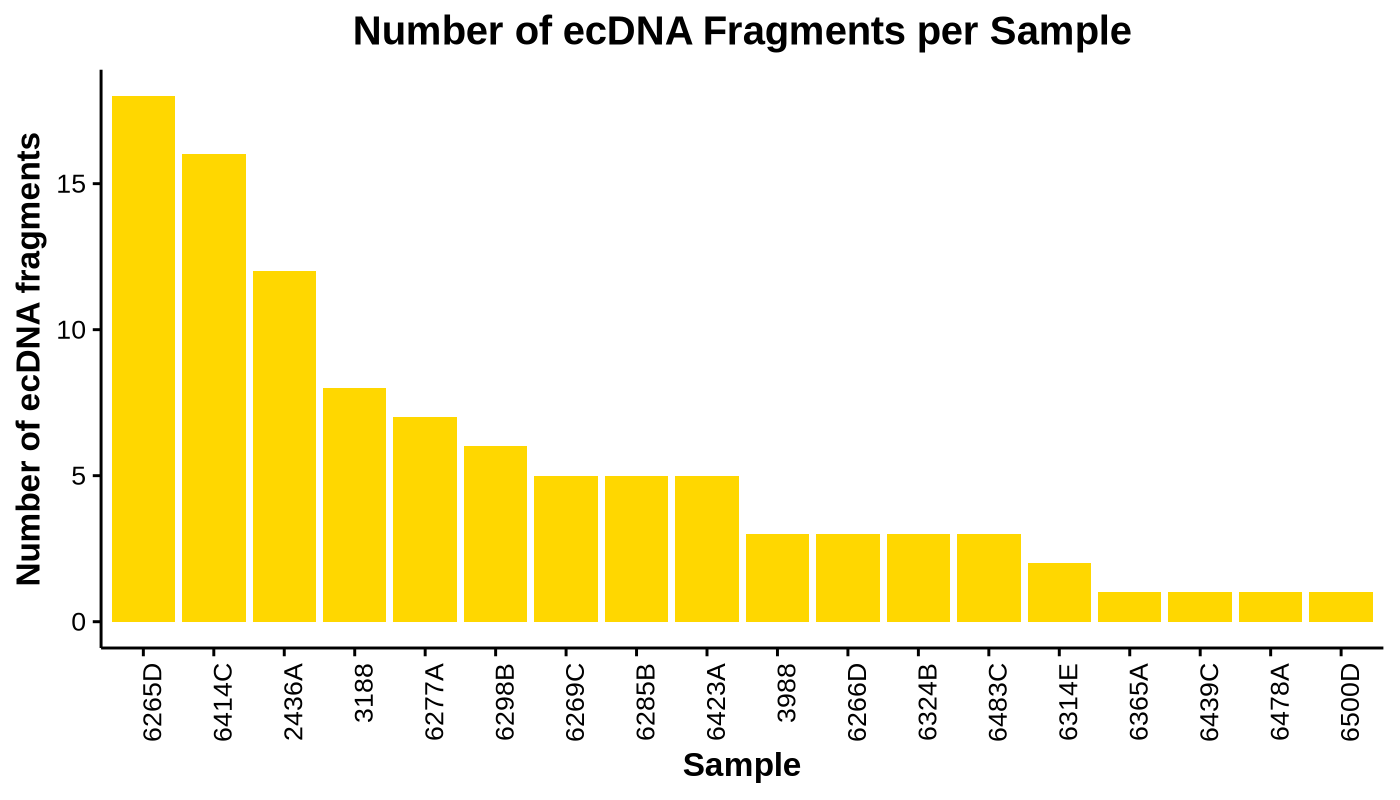

In [20]:
# ecDNA counts and fragment summaries
# ==================================================
ecdna_counts <- ecdna %>%
  filter(label == "ecDNA") %>%
  count(sample, name = "ecDNA_count")
print(ecdna_counts)

ecbed <- ecbed %>% filter(!grepl("^#", chr))

ecbed_counts <- ecbed %>% count(sample, name = "fragments_count")
print(ecbed_counts)

chrom_counts <- ecbed %>%
  count(chr, name = "fragment_count") %>%
  arrange(desc(fragment_count))
chrom_counts$chr <- factor(chrom_counts$chr, levels = chrom_counts$chr)

p_frag_chr <- ggplot(chrom_counts, aes(x = chr, y = fragment_count)) +
  geom_col(fill = "gold") +
  labs(
    title = "Overall Distribution of ecDNA Fragments per Chromosome",
    x = "Chromosome",
    y = "Number of ecDNA fragments"
  ) +
  theme_pub(12) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
print(p_frag_chr)

fragment_counts <- ecbed %>%
  count(sample, name = "fragments_count") %>%
  arrange(desc(fragments_count))
fragment_counts$sample <- factor(fragment_counts$sample, levels = fragment_counts$sample)

p_frag_sample <- ggplot(fragment_counts, aes(x = sample, y = fragments_count)) +
  geom_col(fill = "gold") +
  labs(
    title = "Number of ecDNA Fragments per Sample",
    x = "Sample",
    y = "Number of ecDNA fragments"
  ) +
  theme_pub(12) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
print(p_frag_sample)
#save_pdf(p_frag_sample, file.path(fig6_dir, "No_ecDNA_Fragments_Sample.pdf"), 5, 5)

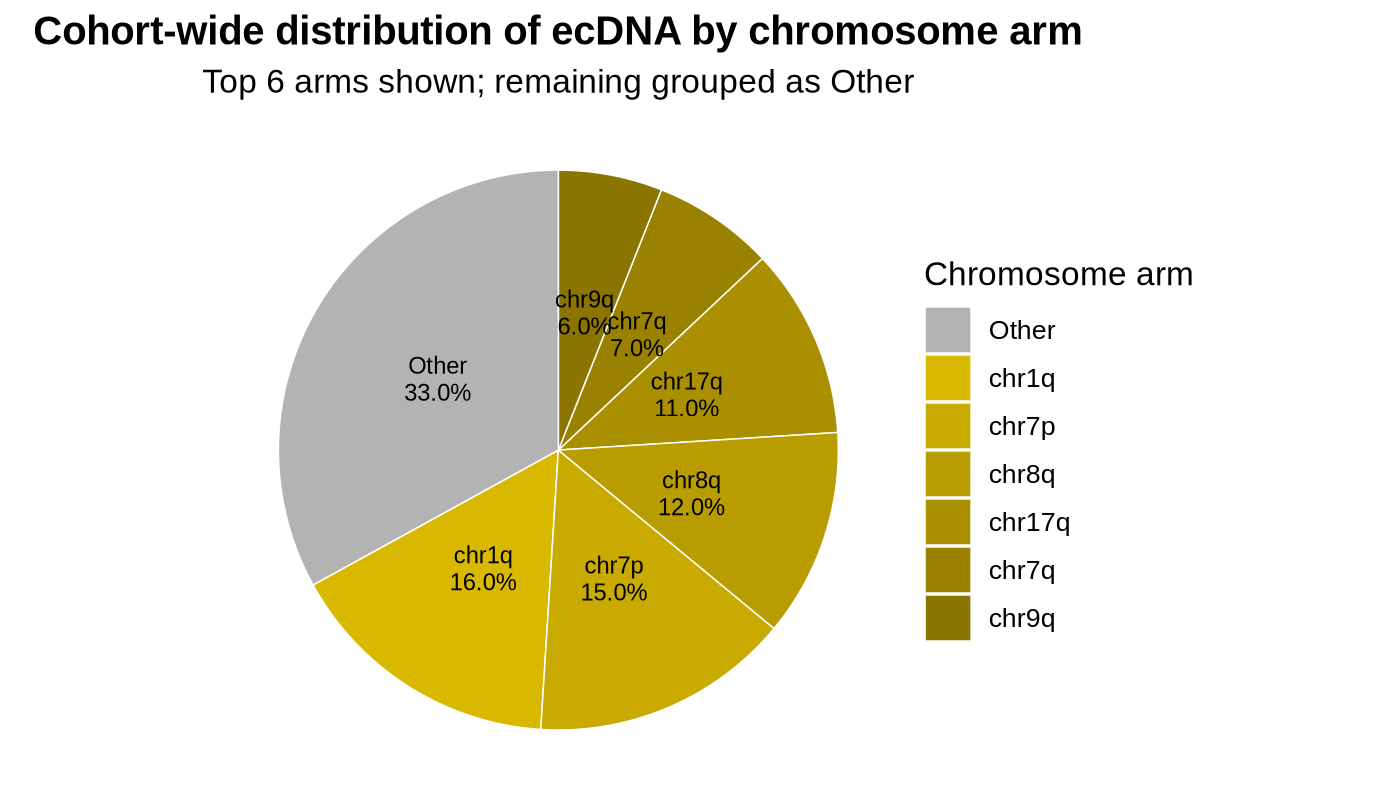

In [24]:
# Cohort-wide distribution of ecDNA by chromosome arm
# ==================================================
ec_with_arm <- read.delim2("/home/mjehangir/telomere-sv-analysis/data/ecDNA_with_tel.bed")

cohort_counts <- ec_with_arm %>%
  distinct(sample, chr_arm, start, end) %>%
  count(Arm = chr_arm, name = "events")

top_n <- 6
min_frac_label <- 0.03

pie_df <- cohort_counts %>%
  mutate(Arm_lumped = fct_lump_n(Arm, n = top_n, w = events, other_level = "Other")) %>%
  group_by(Arm_lumped) %>%
  summarise(events = sum(events), .groups = "drop") %>%
  mutate(
    frac = events / sum(events),
    label = if_else(frac >= min_frac_label,
                    paste0(as.character(Arm_lumped), "\n", percent(frac, accuracy = 0.1)),
                    "")
  ) %>%
  mutate(Arm_lumped = fct_reorder(Arm_lumped, events, .desc = TRUE))

arm_levels <- levels(pie_df$Arm_lumped)
top_arms <- arm_levels[arm_levels != "Other"]
gold_colors <- scales::seq_gradient_pal("gold2", "gold4", "Lab")(seq(0.2, 1, length.out = length(top_arms)))
arm_colors <- c(setNames(gold_colors, top_arms), Other = "grey70")

p_arm_pie <- ggplot(pie_df, aes(x = "", y = frac, fill = Arm_lumped)) +
  geom_col(width = 1, color = "white", linewidth = 0.25) +
  coord_polar(theta = "y") +
  geom_text(aes(label = label), position = position_stack(vjust = 0.5), size = 3, lineheight = 0.95) +
  scale_fill_manual(values = arm_colors) +
  labs(
    title = "Cohort-wide distribution of ecDNA by chromosome arm",
    subtitle = paste0("Top ", top_n, " arms shown; remaining grouped as Other"),
    fill = "Chromosome arm"
  ) +
  theme_void(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5))

print(p_arm_pie)
#save_pdf(p_arm_pie, file.path(fig6_dir, "piechart_ecDNA_prop_per_arm.pdf"), 5, 5)

Rows: 20 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): ID, surgical
dbl (9): Age, Grade, CDKN2A/B, TP53, ATRX, onco_Alterations, ONT_Alterations...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


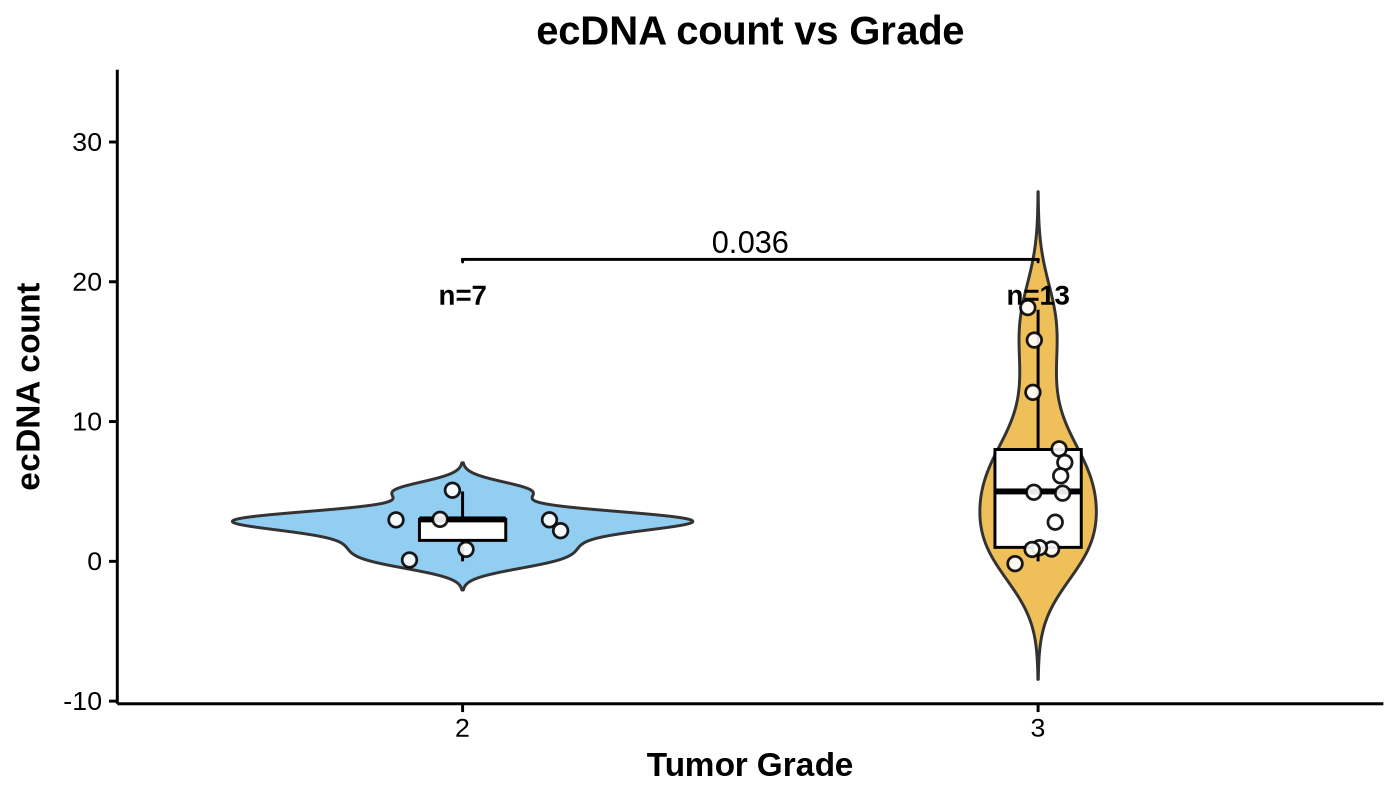

In [23]:
# Clinical data integration and ecDNA count vs grade
# ==================================================
clinical_data <- read_tsv("clinical_data_merged.txt", na = c("NA", "not available", ""))

merged_data <- clinical_data %>%
  left_join(ecbed %>% count(sample, name = "ecDNA_count"), by = c("ID" = "sample")) %>%
  mutate(
    ecDNA_count = replace_na(ecDNA_count, 0),
    ecDNA_group = factor(if_else(ecDNA_count > median(ecDNA_count), "High", "Low"), levels = c("Low", "High")),
    surv_obj = Surv(days, dead)
  )

grade_subset <- merged_data %>%
  filter(Grade %in% c(2, 3), !is.na(ecDNA_count)) %>%
  mutate(Grade = factor(Grade))

grade_cols <- c("2" = "#56B4E9", "3" = "#E69F00")
y_max <- max(grade_subset$ecDNA_count, na.rm = TRUE)

p_grade <- ggplot(grade_subset, aes(x = Grade, y = ecDNA_count, fill = Grade)) +
  geom_violin(trim = FALSE, width = 0.8, alpha = 0.65) +
  geom_boxplot(width = 0.15, outlier.shape = NA, fill = "white", color = "black", linewidth = 0.5) +
  ggforce::geom_sina(shape = 21, size = 2, stroke = 0.7, fill = "white", alpha = 0.9, maxwidth = 0.5) +
  stat_summary(
    fun.data = function(x) data.frame(y = y_max * 1.02, label = paste0("n=", length(x))),
    geom = "text", size = 3.5, fontface = "bold", vjust = 0
  ) +
  stat_compare_means(
    method = "t.test",
    comparisons = list(c("2", "3")),
    label = "p.format",
    bracket.size = 0.5,
    tip.length = 0.01,
    label.y = y_max * 1.15
  ) +
  scale_fill_manual(values = grade_cols) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.25))) +
  labs(x = "Tumor Grade", y = "ecDNA count", title = "ecDNA count vs Grade") +
  theme_pub(12) +
  theme(legend.position = "none")

print(p_grade)

In [26]:
# 8. ecDNA genes and repeats using CHM13 annotations
# ==================================================
gr_exon <- read_bed(file.path(base_dir, "EXONS_chm13.bed"))
gr_repeats <- read_bed(file.path(base_dir, "REPEATS_chm13.bed"))

ecdna_df <- ecbed %>%
  mutate(
    chrom = as.character(chr),
    start = as.numeric(start),
    end = as.numeric(end)
  ) %>%
  select(chrom, start, end, circ_id, fragment_id, sample)

ecdna_genes <- bed_intersect(ecdna_df, gr_exon)
ecdna_repeats <- bed_intersect(ecdna_df, gr_repeats)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


Warning message in geom_text_repel(data = label_df %>% filter(label != ""), aes(x = chrom, :
“Ignoring unknown parameters: `segment.linewidth`”


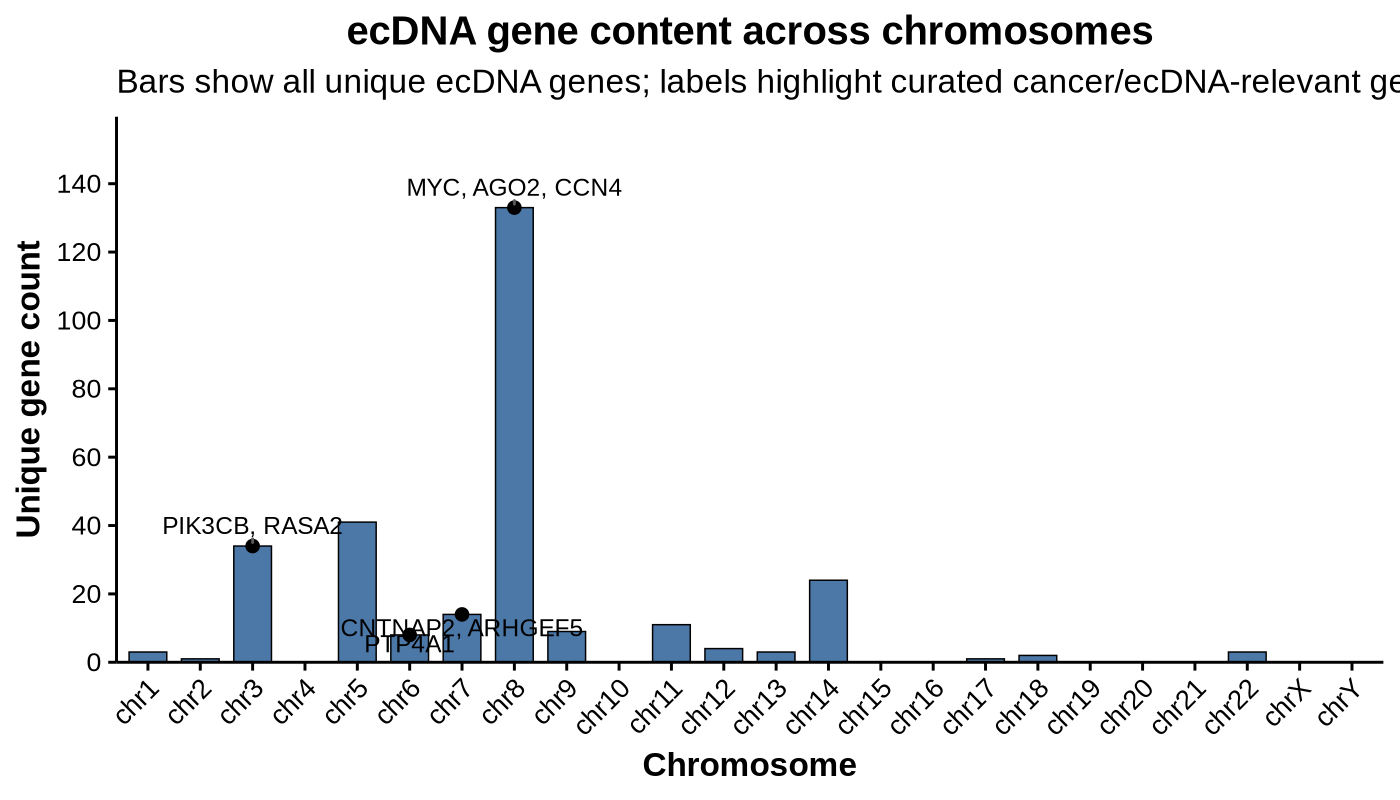

In [27]:
#  Gene counts by chromosome
chr_levels <- c(paste0("chr", 1:22), "chrX", "chrY")
col_gene_bar <- "#4C78A8"
max_labels_per_chr <- 3

canonical_ecdna_genes <- c(
  "MYC", "EGFR", "MDM2", "CDK4", "PDGFRA", "ERBB2", "TERT",
  "CCND1", "CCNE1", "CDK6", "MDM4", "MYCN", "SOX2", "E2F3",
  "KRAS", "AKT1", "AKT3", "BCL2L1", "MCL1", "IGF1R",
  "NKX2-1", "PAX8", "NEDD9"
)
secondary_cancer_genes <- c(
  "ASPM", "ARHGEF5", "EPHA3", "PIK3CB", "TRIB1", "SQLE",
  "FAM83H", "AGO2", "MAPK15", "PTP4A1", "CCN4", "KCNK9",
  "CNTNAP2", "BRCA2", "MTSS1", "NDRG1", "RASA2"
)
important_genes <- unique(c(canonical_ecdna_genes, secondary_cancer_genes))

gene_hits <- ecdna_genes %>%
  transmute(
    sample = as.character(sample.x),
    circ_id = as.character(circ_id.x),
    fragment_id = as.character(fragment_id.x),
    chrom = as.character(chrom),
    gene = as.character(score.y)
  ) %>%
  filter(!is.na(chrom), !is.na(gene), gene != "", chrom %in% chr_levels) %>%
  distinct(sample, circ_id, fragment_id, chrom, gene)

gene_chr_count <- gene_hits %>%
  distinct(chrom, gene) %>%
  count(chrom, name = "n_genes") %>%
  mutate(chrom = factor(chrom, levels = chr_levels)) %>%
  arrange(chrom)

gene_chr_count <- data.frame(chrom = factor(chr_levels, levels = chr_levels)) %>%
  left_join(gene_chr_count, by = "chrom") %>%
  mutate(n_genes = ifelse(is.na(n_genes), 0, n_genes))

label_df <- gene_hits %>%
  filter(gene %in% important_genes) %>%
  mutate(label_group = ifelse(gene %in% canonical_ecdna_genes, "canonical", "secondary")) %>%
  count(chrom, gene, label_group, name = "n_fragments") %>%
  group_by(chrom) %>%
  arrange(label_group, desc(n_fragments), gene, .by_group = TRUE) %>%
  slice_head(n = max_labels_per_chr) %>%
  summarise(label = paste(gene, collapse = ", "), .groups = "drop") %>%
  mutate(chrom = factor(chrom, levels = chr_levels)) %>%
  right_join(gene_chr_count, by = "chrom") %>%
  mutate(label = ifelse(is.na(label), "", label))

p_genes <- ggplot(gene_chr_count, aes(x = chrom, y = n_genes)) +
  geom_col(width = 0.72, fill = col_gene_bar, colour = "black", linewidth = 0.25) +
  geom_point(data = label_df %>% filter(label != ""), aes(x = chrom, y = n_genes), inherit.aes = FALSE, size = 1.8) +
  geom_text_repel(
    data = label_df %>% filter(label != ""),
    aes(x = chrom, y = n_genes, label = label),
    inherit.aes = FALSE,
    size = 3.1, min.segment.length = 0, box.padding = 0.25,
    point.padding = 0.2, segment.color = "grey35", segment.linewidth = 0.35,
    force = 1.1, direction = "y", max.overlaps = Inf
  ) +
  scale_x_discrete(drop = FALSE) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.20)), breaks = pretty_breaks(n = 6)) +
  coord_cartesian(clip = "off") +
  labs(
    title = "ecDNA gene content across chromosomes",
    subtitle = "Bars show all unique ecDNA genes; labels highlight curated cancer/ecDNA-relevant genes",
    x = "Chromosome", y = "Unique gene count"
  ) +
  theme_pub(12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

print(p_genes)
#save_pdf(p_genes, file.path(fig3_dir, "ecDNA_Genes_per_Chromosome.pdf"), 5, 4)

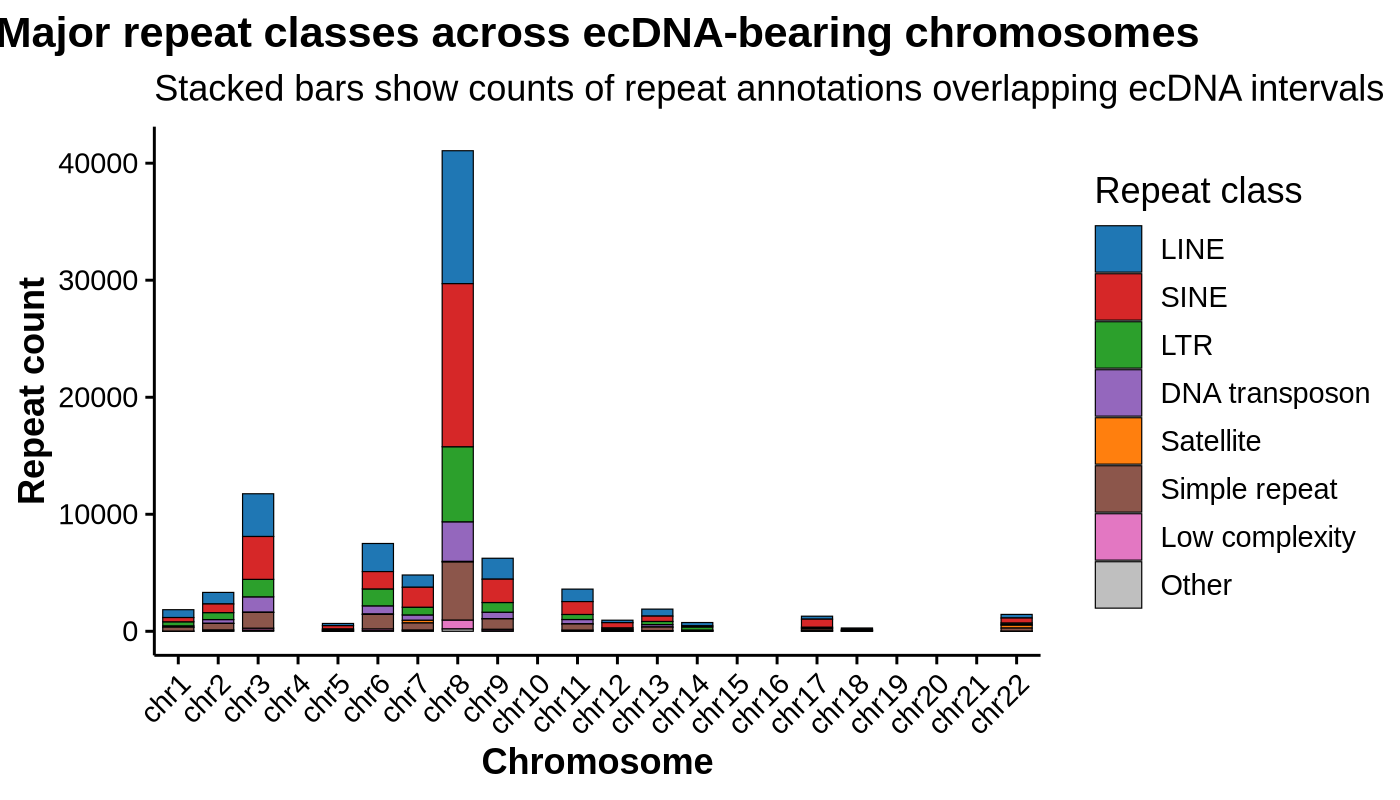

In [28]:
# Repeat classes by chromosome
chr_levels_repeat <- c(paste0("chr", 1:22))

repeat_major_chr <- ecdna_repeats %>%
  transmute(
    chrom = as.character(chrom),
    repeat_type_raw = sub("/.*", "", as.character(score.y))
  ) %>%
  filter(!is.na(chrom), !is.na(repeat_type_raw), repeat_type_raw != "", chrom %in% chr_levels_repeat) %>%
  mutate(
    repeat_type = case_when(
      repeat_type_raw == "LINE" ~ "LINE",
      repeat_type_raw == "SINE" ~ "SINE",
      repeat_type_raw == "LTR" ~ "LTR",
      repeat_type_raw == "DNA" ~ "DNA transposon",
      repeat_type_raw == "Satellite" ~ "Satellite",
      repeat_type_raw == "Simple_repeat" ~ "Simple repeat",
      repeat_type_raw == "Low_complexity" ~ "Low complexity",
      TRUE ~ "Other"
    )
  ) %>%
  count(chrom, repeat_type, name = "n")

repeat_major_chr$chrom <- factor(repeat_major_chr$chrom, levels = chr_levels_repeat)
repeat_major_chr$repeat_type <- factor(
  repeat_major_chr$repeat_type,
  levels = c("LINE", "SINE", "LTR", "DNA transposon", "Satellite", "Simple repeat", "Low complexity", "Other")
)

repeat_cols <- c(
  "LINE" = "#1F77B4",
  "SINE" = "#D62728",
  "LTR" = "#2CA02C",
  "DNA transposon" = "#9467BD",
  "Satellite" = "#FF7F0E",
  "Simple repeat" = "#8C564B",
  "Low complexity" = "#E377C2",
  "Other" = "grey75"
)

p_repeat <- ggplot(repeat_major_chr, aes(x = chrom, y = n, fill = repeat_type)) +
  geom_col(width = 0.78, colour = "black", linewidth = 0.2) +
  scale_fill_manual(values = repeat_cols, drop = FALSE) +
  scale_x_discrete(drop = FALSE) +
  labs(
    title = "Major repeat classes across ecDNA-bearing chromosomes",
    subtitle = "Stacked bars show counts of repeat annotations overlapping ecDNA intervals",
    x = "Chromosome", y = "Repeat count", fill = "Repeat class"
  ) +
  theme_pub(13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1), legend.position = "right")

print(p_repeat)
#save_pdf(p_repeat, file.path(fig3_dir, "ecDNA_Repeats_per_Chromosome.pdf"), 8, 4)

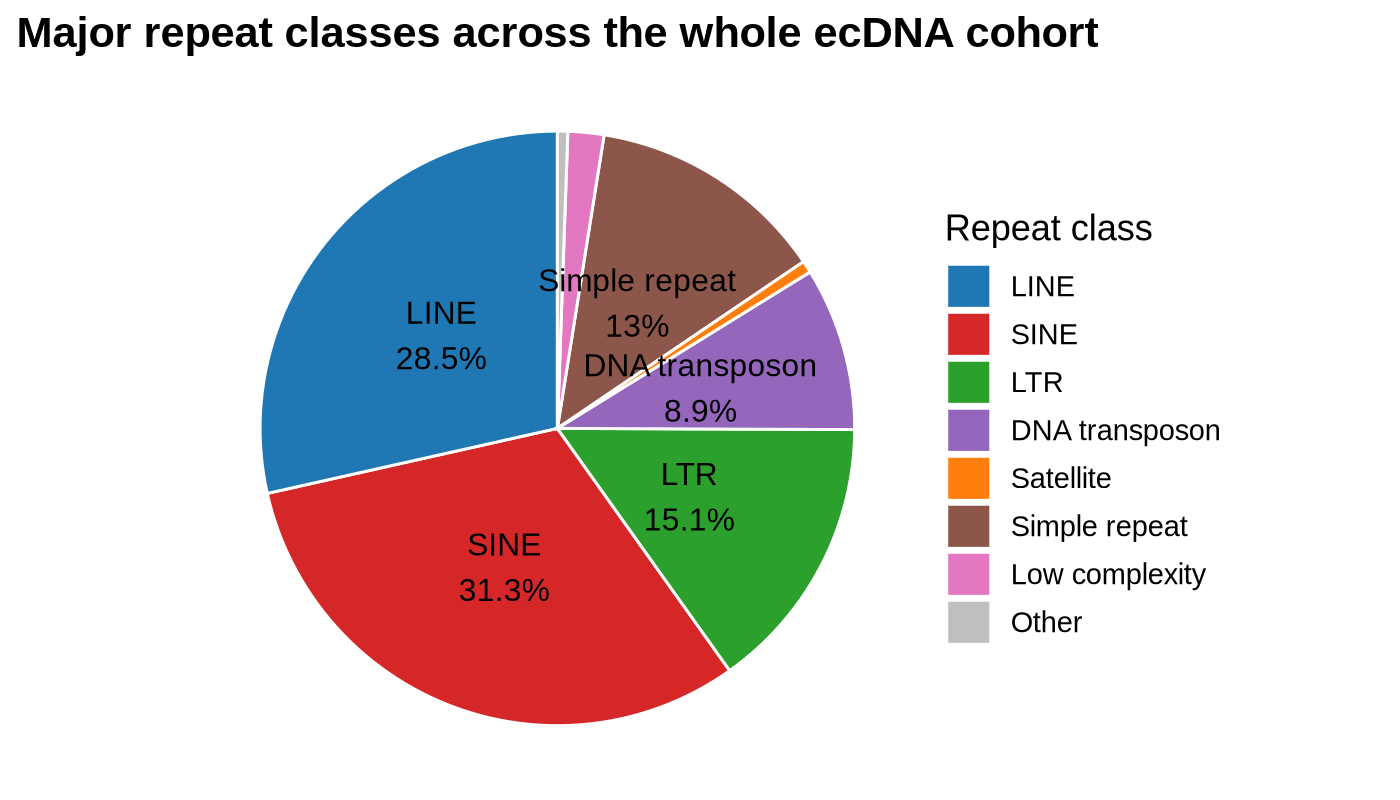

In [29]:
#  Whole-cohort repeat class pie chart
repeat_cohort_pct <- ecdna_repeats %>%
  transmute(repeat_type_raw = sub("/.*", "", as.character(score.y))) %>%
  filter(!is.na(repeat_type_raw), repeat_type_raw != "") %>%
  mutate(
    repeat_type = case_when(
      repeat_type_raw == "LINE" ~ "LINE",
      repeat_type_raw == "SINE" ~ "SINE",
      repeat_type_raw == "LTR" ~ "LTR",
      repeat_type_raw == "DNA" ~ "DNA transposon",
      repeat_type_raw == "Satellite" ~ "Satellite",
      repeat_type_raw == "Simple_repeat" ~ "Simple repeat",
      repeat_type_raw == "Low_complexity" ~ "Low complexity",
      TRUE ~ "Other"
    )
  ) %>%
  count(repeat_type, name = "n") %>%
  mutate(percent = 100 * n / sum(n), label = paste0(repeat_type, "\n", round(percent, 1), "%")) %>%
  arrange(desc(percent))

repeat_cohort_pct$repeat_type <- factor(
  repeat_cohort_pct$repeat_type,
  levels = c("LINE", "SINE", "LTR", "DNA transposon", "Satellite", "Simple repeat", "Low complexity", "Other")
)

p_repeat_pie <- ggplot(repeat_cohort_pct, aes(x = "", y = n, fill = repeat_type)) +
  geom_col(width = 1, color = "white", linewidth = 0.5) +
  coord_polar(theta = "y") +
  scale_fill_manual(values = repeat_cols, drop = FALSE) +
  geom_text(aes(label = ifelse(percent >= 3, label, "")), position = position_stack(vjust = 0.5), size = 4, color = "black") +
  labs(title = "Major repeat classes across the whole ecDNA cohort", fill = "Repeat class") +
  theme_void(base_size = 13) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5), legend.position = "right")

print(p_repeat_pie)
#save_pdf(p_repeat_pie, file.path(fig3_dir, "piechart_ecDNA_Repeats.pdf"), 4, 4)